In [22]:
import fitz
import re
from pathlib import Path 
import pymupdf4llm


In [23]:
input_dir = Path("../../data/raw")
output_dir = Path("../../data/processed")

In [3]:
    
for pdf in input_dir.glob("*.pdf"):
    md_text = pymupdf4llm.to_markdown(str(pdf))

    output_file = output_dir / f"{pdf.stem}.md"

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(md_text)

    print(f"Converted {pdf.name}")

Converted deepseek.pdf
Converted toolformer.pdf
Converted llava.pdf
Converted gpt.pdf
Converted attention.pdf
Converted sentence_bert.pdf
Converted dspy.pdf
Converted beir.pdf
Converted hyde.pdf
Converted lora.pdf
Converted rag.pdf
Converted clip.pdf
Converted paged_attention.pdf
Converted qlora.pdf
Converted self_rag.pdf
Converted qwen2.pdf
Converted bert.pdf
Converted longformer.pdf
Converted crag.pdf
Converted colbert.pdf
Converted colbert2.pdf
Converted react.pdf
Converted realm.pdf
Converted kv_cache.pdf
Converted dense_retireval.pdf
Converted flas_attention.pdf
Converted blip.pdf


In [24]:
def clean_markdown(text):

    # remove image placeholders
    text = re.sub(
        r"==>\s*picture\s*\[.*?\]\s*intentionally omitted\s*<==",
        "",
        text,
        flags=re.IGNORECASE
    )

    # remove references / acknowledgements
    stop_headers = [
    r"^##\s+(?:\*\*)?references(?:\*\*)?",
    r"^##\s+(?:\*\*)?bibliography(?:\*\*)?",
    r"^##\s+(?:\*\*)?acknowledg(?:ement|ements)?(?:\*\*)?",
]

    lines = text.split("\n")

    cleaned_lines = []

    for line in lines:

        stop = False

        for pattern in stop_headers:
            if re.match(pattern, line.strip(), re.IGNORECASE):
                stop = True
                break

        if stop:
            break

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # remove excessive whitespace
    text = re.sub(r"\n{3,}", "\n\n", text)

    # merge broken sentence linebreaks
    text = re.sub(r"(?<!\n)\n(?!#|\n)", " ", text)

    # collapse spaces
    text = re.sub(r"[ \t]+", " ", text)

    return text.strip()

In [25]:
md_file = output_dir / "beir.md"\

with open(md_file, "r", encoding="utf-8") as f:
    md_text = f.read()

cleaned_text = clean_markdown(md_text)
cleaned_text

'****\n\n# **BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models** \n\n**Nandan Thakur, Nils Reimers, Andreas Rücklé** _[∗]_ **, Abhishek Srivastava, Iryna Gurevych** Ubiquitous Knowledge Processing Lab (UKP-TUDA) Department of Computer Science, Technische Universität Darmstadt \n\n``` www.ukp.tu-darmstadt.de ```\n\n## **Abstract** \n\nExisting neural information retrieval (IR) models have often been studied in homogeneous and narrow settings, which has considerably limited insights into their out-of-distribution (OOD) generalization capabilities. To address this, and to facilitate researchers to broadly evaluate the effectiveness of their models, we introduce **Be** nchmarking- **IR** ( **BEIR** ), a robust and heterogeneous evaluation benchmark for information retrieval. We leverage a careful selection of 18 publicly available datasets from diverse text retrieval tasks and domains and evaluate 10 state-of-theart retrieval systems including lexical

In [ ]:
def parse_sections(md_text):

    lines = md_text.split("\n")

    nodes = []

    current_section = None
    current_subsection = None

    buffer = []

    KNOWN_HEADERS = {
        "abstract",
        "introduction",
        "background",
        "related work",
        "method",
        "methods",
        "approach",
        "model architecture",
        "training",
        "experiments",
        "results",
        "evaluation",
        "discussion",
        "limitations",
        "conclusion",
        "references",
        "appendix"
    }

    def flush_buffer():
        nonlocal buffer

        content = "\n".join(buffer).strip()

        # don't create empty chunks and drop front matter sections with little content
        if (
            current_section is not None
            and content
            and len(content.split()) > 20
            ):

            nodes.append({
                "section": current_section,
                "subsection": current_subsection,
                "text": content
            })

        buffer = []

    for line in lines:

        line = line.strip()

        # markdown header
        match = re.match(
            r"^(#{1,6})\s+(.+)$",
            line
        )

        if match:

            level = len(match.group(1))
            title = match.group(2).strip()

            # remove markdown bold
            title = re.sub(r"\*\*", "", title)
            title = re.sub(r"\s+", " ", title)

            title_lower = title.lower()

            is_valid_header = False

            numbering_match = re.match(
                r"^(\d+(?:\.\d+)*)\s+(.+)$",
                title
            )

            # ---------- NUMBERED HEADERS ----------
            if numbering_match:

                numbering = numbering_match.group(1)
                depth = numbering.count(".")

                is_valid_header = True

                flush_buffer()

                # 3 Title
                if depth == 0:

                    current_section = title
                    current_subsection = None

                # 3.1 Subtitle
                elif depth == 1:

                    current_subsection = title

                # 3.2.1 Child subsection
                elif depth >= 2:

                    # keep under same subsection
                    # append title into body for context
                    buffer.append(f"\n{title}\n")

                continue

            # ---------- SEMANTIC HEADERS ----------
            for known in KNOWN_HEADERS:
                if known in title_lower:

                    is_valid_header = True

                    flush_buffer()

                    current_section = title
                    current_subsection = None
                    break

            if is_valid_header:
                continue

        # normal content
        buffer.append(line)

    flush_buffer()

    return nodes

In [27]:
nodes = parse_sections(cleaned_text)
nodes[:5]

[{'section': 'BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models',
  'subsection': None,
  'text': '**Nandan Thakur, Nils Reimers, Andreas Rücklé** _[∗]_ **, Abhishek Srivastava, Iryna Gurevych** Ubiquitous Knowledge Processing Lab (UKP-TUDA) Department of Computer Science, Technische Universität Darmstadt\n\n``` www.ukp.tu-darmstadt.de ```'},
 {'section': 'Abstract',
  'subsection': None,
  'text': 'Existing neural information retrieval (IR) models have often been studied in homogeneous and narrow settings, which has considerably limited insights into their out-of-distribution (OOD) generalization capabilities. To address this, and to facilitate researchers to broadly evaluate the effectiveness of their models, we introduce **Be** nchmarking- **IR** ( **BEIR** ), a robust and heterogeneous evaluation benchmark for information retrieval. We leverage a careful selection of 18 publicly available datasets from diverse text retrieval tasks and domains 

In [28]:
import configparser
from transformers import AutoTokenizer

# ---------------- CONFIG ---------------- #
config = configparser.ConfigParser()
config.read('../constants.ini')


MODEL_NAME = config.get('CHUNK', 'MODEL_NAME')
CHUNK_SIZE = config.getint('CHUNK', 'CHUNK_SIZE')
OVERLAP = config.getint('CHUNK', 'OVERLAP')
MIN_SUBSECTION_TOKENS = config.getint('CHUNK', 'MIN_SUBSECTION_TOKENS')
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

In [29]:
def count_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False))


def chunk_tokens(text):

    tokens = tokenizer.encode(
        text,
        add_special_tokens=False
    )

    chunks = []

    start = 0

    while start < len(tokens):

        end = start + CHUNK_SIZE

        chunk_tokens = tokens[start:end]

        chunk_text = tokenizer.decode(chunk_tokens)

        chunks.append(chunk_text)

        start += CHUNK_SIZE - OVERLAP

    return chunks

def chunk_text_semantically(
    text,
    chunk_size=500,
    overlap=75
):
    """
    Paragraph-aware token chunking.

    Strategy:
    1. Split by paragraphs
    2. Greedily pack paragraphs
    3. Sliding window fallback for huge paragraphs
    """

    paragraphs = [
        p.strip()
        for p in text.split("\n\n")
        if p.strip()
    ]

    chunks = []

    current_chunk = []
    current_tokens = 0

    for para in paragraphs:

        para_tokens = count_tokens(para)

        # -------------------------------
        # CASE 1: paragraph itself huge
        # -------------------------------
        if para_tokens > chunk_size:

            # flush existing chunk first
            if current_chunk:

                chunks.append(
                    "\n\n".join(current_chunk)
                )

                current_chunk = []
                current_tokens = 0

            tokens = tokenizer.encode(
                para,
                add_special_tokens=False
            )

            start = 0

            while start < len(tokens):

                end = start + chunk_size

                chunk_tokens = tokens[start:end]

                chunk_text = tokenizer.decode(
                    chunk_tokens
                )

                chunks.append(chunk_text)

                start += (
                    chunk_size - overlap
                )

            continue

        # -------------------------------
        # CASE 2: greedy paragraph packing
        # -------------------------------
        if (
            current_tokens + para_tokens
            <= chunk_size
        ):

            current_chunk.append(para)
            current_tokens += para_tokens

        else:

            chunks.append(
                "\n\n".join(current_chunk)
            )

            current_chunk = [para]
            current_tokens = para_tokens

    # final chunk
    if current_chunk:

        chunks.append(
            "\n\n".join(current_chunk)
        )
    if (
    len(chunks) > 1
    and count_tokens(chunks[-1]) < 150
    ):
        chunks[-2] += "\n\n" + chunks[-1]
        chunks.pop()
    return chunks

def merge_small_subsections(nodes):

    merged = []

    buffer = None

    for node in nodes:

        token_count = count_tokens(node["text"])
        print(f"Section: {node['section']} | Subsection: {node['subsection']} | Tokens: {token_count}")
        if token_count >= MIN_SUBSECTION_TOKENS:

            if buffer:
                merged.append(buffer)
                buffer = None

            merged.append(node)

        else:

            if buffer is None:

                buffer = node.copy()

            else:

                # only merge within same section
                if (
                    buffer["section"] ==
                    node["section"]
                ):

                    buffer["text"] += (
                        f"\n\n{node['subsection']}\n\n"
                        + node["text"]
                    )

                else:

                    merged.append(buffer)
                    buffer = node.copy()

    if buffer:
        merged.append(buffer)

    return merged

In [30]:
sections = merge_small_subsections(nodes)
sections[:5]

Section: BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models | Subsection: None | Tokens: 74
Section: Abstract | Subsection: None | Tokens: 251
Section: 1 Introduction | Subsection: None | Tokens: 1357
Section: 2 Related Work and Background | Subsection: None | Tokens: 206
Section: 2 Related Work and Background | Subsection: 2.1 Neural Retrieval | Tokens: 568
Section: 3 The BEIR Benchmark | Subsection: None | Tokens: 2309
Section: 3 The BEIR Benchmark | Subsection: 3.1 Dataset and Diversity Analysis | Tokens: 179
Section: 3 The BEIR Benchmark | Subsection: 3.2 BEIR Software and Framework | Tokens: 1185
Section: 3 The BEIR Benchmark | Subsection: 3.3 Evaluation Metric | Tokens: 193
Section: 4 Experimental Setup | Subsection: None | Tokens: 1340
Section: 5 Results and Analysis | Subsection: None | Tokens: 3010
Section: 5 Results and Analysis | Subsection: 5.1 Efficiency: Retrieval Latency and Index Sizes | Tokens: 784
Section: 6 Impact of Annotation S

[{'section': 'BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models',
  'subsection': None,
  'text': '**Nandan Thakur, Nils Reimers, Andreas Rücklé** _[∗]_ **, Abhishek Srivastava, Iryna Gurevych** Ubiquitous Knowledge Processing Lab (UKP-TUDA) Department of Computer Science, Technische Universität Darmstadt\n\n``` www.ukp.tu-darmstadt.de ```'},
 {'section': 'Abstract',
  'subsection': None,
  'text': 'Existing neural information retrieval (IR) models have often been studied in homogeneous and narrow settings, which has considerably limited insights into their out-of-distribution (OOD) generalization capabilities. To address this, and to facilitate researchers to broadly evaluate the effectiveness of their models, we introduce **Be** nchmarking- **IR** ( **BEIR** ), a robust and heterogeneous evaluation benchmark for information retrieval. We leverage a careful selection of 18 publicly available datasets from diverse text retrieval tasks and domains 

In [31]:
for section in sections:
    print(f"Section: {section['section']} | Subsection: {section['subsection']} | Tokens: {count_tokens(section['text'])}")

Section: BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models | Subsection: None | Tokens: 74
Section: Abstract | Subsection: None | Tokens: 251
Section: 1 Introduction | Subsection: None | Tokens: 1357
Section: 2 Related Work and Background | Subsection: None | Tokens: 206
Section: 2 Related Work and Background | Subsection: 2.1 Neural Retrieval | Tokens: 568
Section: 3 The BEIR Benchmark | Subsection: None | Tokens: 2309
Section: 3 The BEIR Benchmark | Subsection: 3.1 Dataset and Diversity Analysis | Tokens: 179
Section: 3 The BEIR Benchmark | Subsection: 3.2 BEIR Software and Framework | Tokens: 1185
Section: 3 The BEIR Benchmark | Subsection: 3.3 Evaluation Metric | Tokens: 193
Section: 4 Experimental Setup | Subsection: None | Tokens: 1340
Section: 5 Results and Analysis | Subsection: None | Tokens: 3010
Section: 5 Results and Analysis | Subsection: 5.1 Efficiency: Retrieval Latency and Index Sizes | Tokens: 784
Section: 6 Impact of Annotation S

In [32]:
all_chunks = []

chunk_id = 0

for node in sections:

    text_chunks = chunk_text_semantically(node["text"])

    for chunk in text_chunks:

        all_chunks.append({
            "paper_id": md_file.stem,
            "section": node["section"],
            "subsection": node["subsection"],
            "chunk_id": chunk_id,
            "token_count": count_tokens(chunk),
            "text": chunk
        })

        chunk_id += 1

        

In [33]:
#without semantic chunking
for chunk in all_chunks:
    print(f"Paper ID: {chunk['paper_id']} | Section: {chunk['section']} | Subsection: {chunk['subsection']} | Chunk ID: {chunk['chunk_id']} | Tokens: {chunk['token_count']}")
    

Paper ID: beir | Section: BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models | Subsection: None | Chunk ID: 0 | Tokens: 74
Paper ID: beir | Section: Abstract | Subsection: None | Chunk ID: 1 | Tokens: 251
Paper ID: beir | Section: 1 Introduction | Subsection: None | Chunk ID: 2 | Tokens: 342
Paper ID: beir | Section: 1 Introduction | Subsection: None | Chunk ID: 3 | Tokens: 399
Paper ID: beir | Section: 1 Introduction | Subsection: None | Chunk ID: 4 | Tokens: 615
Paper ID: beir | Section: 2 Related Work and Background | Subsection: None | Chunk ID: 5 | Tokens: 206
Paper ID: beir | Section: 2 Related Work and Background | Subsection: 2.1 Neural Retrieval | Chunk ID: 6 | Tokens: 568
Paper ID: beir | Section: 3 The BEIR Benchmark | Subsection: None | Chunk ID: 7 | Tokens: 446
Paper ID: beir | Section: 3 The BEIR Benchmark | Subsection: None | Chunk ID: 8 | Tokens: 500
Paper ID: beir | Section: 3 The BEIR Benchmark | Subsection: None | Chunk ID: 9 | T

In [34]:
#write first 5 sections to a file for manual inspection
with open(output_dir / "sample_chunks.txt", "w", encoding="utf-8") as f:
    for chunk in all_chunks[:5]:
        f.write(f"Paper ID: {chunk['paper_id']} | Section: {chunk['section']} | Subsection: {chunk['subsection']} | Chunk ID: {chunk['chunk_id']} | Tokens: {chunk['token_count']}\n")
        f.write(chunk["text"])
        f.write("\n\n---\n\n")

In [38]:
import json

chunk_dir = Path("../../data/chunks")

token_counts = []

for path in chunk_dir.glob("*.json"):
    with open(path, "r", encoding="utf-8") as f:
        chunks = json.load(f)
    token_counts.extend(chunk["token_count"] for chunk in chunks)
print(f"Total chunks: {len(token_counts)}")
avg_size = sum(token_counts) / len(token_counts)
min_size = min(token_counts)
max_size = max(token_counts)
median_size = sorted(token_counts)[len(token_counts) // 2]

print(f"Chunks: {len(token_counts)}")
print(f"Average chunk size: {avg_size:.2f}")
print(f"Min chunk size: {min_size}")
print(f"Max chunk size: {max_size}")
print(f"Median chunk size: {median_size}")

Total chunks: 1065
Chunks: 1065
Average chunk size: 359.89
Min chunk size: 9
Max chunk size: 640
Median chunk size: 389


Matplotlib is building the font cache; this may take a moment.


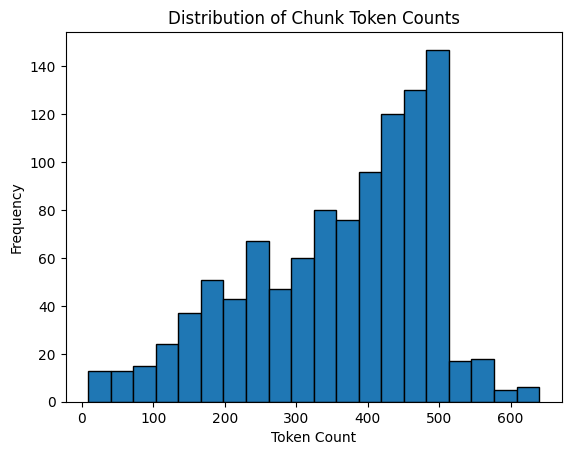

In [41]:
#plot a histogram of token counts
import matplotlib.pyplot as plt
plt.hist(token_counts, bins=20, edgecolor='black')
plt.title("Distribution of Chunk Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()